# Template Extraction — Quick Notebook
Paste a few atom-mapped reaction SMILES and extract LocalTemplate templates at radii 0–5.

In [1]:
import os, sys, pandas as pd
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

ROOT       = os.getcwd()   # must be E:/Pistachio_Reagent_Prediction/R_2602
LOCAL_TMPL = os.path.join(ROOT, 'LocalTemplate')
sys.path.insert(0, LOCAL_TMPL)

from localtemplate.template_extractor import TemplateExtractor
from rdkit import Chem
from rdkit.Chem import Draw

def strip_atom_mapping(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)

def visualize_reaction(rxn_smiles: str, img_size = (300, 300), **kwargs):
    reactants, products = rxn_smiles.split('>>')

    return Draw.MolsToGridImage(
        [Chem.MolFromSmiles(reactants), Chem.MolFromSmiles(products)],
        legends = ['reactant', 'product'], subImgSize=img_size,
        **kwargs
    )

In [3]:
df = pd.read_csv("sample.csv")

In [13]:
RADII = [0, 1, 2, 3]
extractors_base = {
    r: TemplateExtractor(
        simplify_aromatic=False, simplify_halide=False,
        include_LGs=False, map_all_atoms=False, radius=r,
    )
    for r in RADII
}
print('Extractors ready:', RADII)

Extractors ready: [0, 1, 2, 3]


In [12]:
RADII = [0, 1, 2, 3]
extractors_LG = {
    r: TemplateExtractor(
        simplify_aromatic=False, simplify_halide=False,
        include_LGs=True, map_all_atoms=False, radius=r,
    )
    for r in RADII
}
print('Extractors ready:', RADII)

Extractors ready: [0, 1, 2, 3]


In [11]:
RADII = [0, 1, 2, 3]
extractors_halide = {
    r: TemplateExtractor(
        simplify_aromatic=False, simplify_halide=True,
        include_LGs=False, map_all_atoms=False, radius=r,
    )
    for r in RADII
}
print('Extractors ready:', RADII)

Extractors ready: [0, 1, 2, 3]


SMILES: [CH3:1]I.[CH2:2]1[CH:3]=[CH:4][c:5]2[cH:6][cH:7][cH:8][cH:9][c:10]12>>[CH3:1][CH:2]1[CH:3]=[CH:4][c:5]2[cH:6][cH:7][cH:8][cH:9][c:10]12
Catalyst: nan
Agent: [Li][CH2]CCC
Solvent: C1CCOC1;Cc1ccccc1


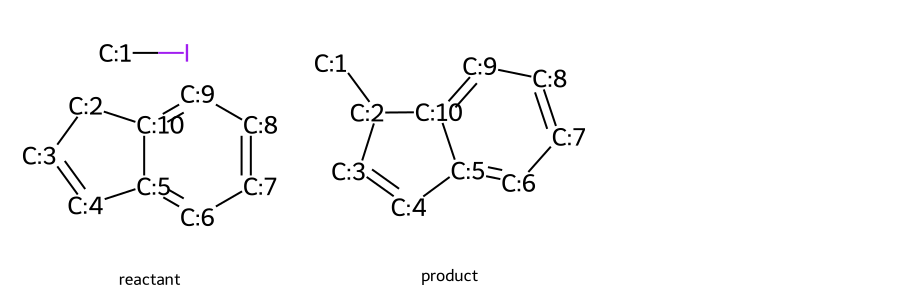

-------------LG----------------
Radius 0: [C:1].[C:2]-I>>[C:1]-[C:2]
Radius 1: [C:3]-[C:2]-[c:4].[C:1]-I>>[C:1]-[C:2](-[C:3])-[c:4]
Radius 2: [c:7]:[c:6]1:[c:5]-[C:4]=[C:3]-[C:2]-1.[C:1]-I>>[C:1]-[C:2]1-[C:3]=[C:4]-[c:5]:[c:6]-1:[c:7]
Radius 3: [c:9]:[c:8]:[c:7]1:[c:5](:[c:6])-[C:4]=[C:3]-[C:2]-1.[C:1]-I>>[C:1]-[C:2]1-[C:3]=[C:4]-[c:5](:[c:6]):[c:7]-1:[c:8]:[c:9]
-------------base----------------
Radius 0: [C:1].[C:2]>>[C:1]-[C:2]
Radius 1: [C:3]-[C:2]-[c:4].[C:1]-I>>[C:1]-[C:2](-[C:3])-[c:4]
Radius 2: [c:7]:[c:6]1:[c:5]-[C:4]=[C:3]-[C:2]-1.[C:1]-I>>[C:1]-[C:2]1-[C:3]=[C:4]-[c:5]:[c:6]-1:[c:7]
Radius 3: [c:9]:[c:8]:[c:7]1:[c:5](:[c:6])-[C:4]=[C:3]-[C:2]-1.[C:1]-I>>[C:1]-[C:2]1-[C:3]=[C:4]-[c:5](:[c:6]):[c:7]-1:[c:8]:[c:9]
-------------halide----------------
Radius 0: [C:1].[C:2]>>[C:1]-[C:2]
Radius 1: [C:3]-[C:2]-[c:4].[C:1]-I>>[C:1]-[C:2](-[C:3])-[c:4]
Radius 2: [c:7]:[c:6]1:[c:5]-[C:4]=[C:3]-[C:2]-1.[C:1]-I>>[C:1]-[C:2]1-[C:3]=[C:4]-[c:5]:[c:6]-1:[c:7]
Radius 3: [c:9]:[c:8]:[c:7]1:[c

In [21]:
rxn = df.iloc[2]

smi = rxn['SMILES']
cat = rxn['Catalyst']
agt = rxn['Agent']
sol = rxn['Solvent']
print('SMILES:', smi)
print('Catalyst:', cat)
print('Agent:', agt)
print('Solvent:', sol)
display(visualize_reaction(smi))

print("-------------LG----------------")
row = {'SMILES': smi}
for r, ext in extractors_LG.items():
        try:
            tmpl = ext(smi, return_template_only=True)
            row[f'template_r{r}'] = tmpl if tmpl is not None else ''
            print(f'Radius {r}:', tmpl)
            # display(visualize_reaction(tmpl))
        except Exception as e:
            row[f'template_r{r}'] = f'ERROR: {type(e).__name__}: {e}'


print("-------------base----------------")
row = {'SMILES': smi}
for r, ext in extractors_base.items():
        try:
            tmpl = ext(smi, return_template_only=True)
            row[f'template_r{r}'] = tmpl if tmpl is not None else ''
            print(f'Radius {r}:', tmpl)
            # display(visualize_reaction(tmpl))
        except Exception as e:
            row[f'template_r{r}'] = f'ERROR: {type(e).__name__}: {e}'

print("-------------halide----------------")
row = {'SMILES': smi}
for r, ext in extractors_halide.items():
        try:
            tmpl = ext(smi, return_template_only=True)
            row[f'template_r{r}'] = tmpl if tmpl is not None else ''
            print(f'Radius {r}:', tmpl)
            # display(visualize_reaction(tmpl))
        except Exception as e:
            row[f'template_r{r}'] = f'ERROR: {type(e).__name__}: {e}'


In [23]:

# 할로겐이 포함되려면 include_LGs=True 필요
# 새로운 extractors 생성 (include_LGs=True로 설정)
extractors_halide_withLG = {
    r: TemplateExtractor(
        simplify_aromatic=False, simplify_halide=True,
        include_LGs=True, map_all_atoms=False, radius=r,  # ← include_LGs=True 추가
    )
    for r in RADII
}

extractors_base_withLG = {
    r: TemplateExtractor(
        simplify_aromatic=False, simplify_halide=False,
        include_LGs=True, map_all_atoms=False, radius=r,  # ← include_LGs=True 추가
    )
    for r in RADII
}

# 같은 반응에서 base vs halide 비교 (include_LGs=True)
rxn_idx = 0
smi = df['SMILES'].iloc[rxn_idx]
print('Input SMILES:')
print(smi)
print('\n' + '='*60)

for radius in [0, 1, 2]:
    print(f'\n--- Radius {radius} (include_LGs=True) ---')
    
    tmpl_base = extractors_base_withLG[radius](smi, return_template_only=True)
    print(f'base (simplify_halide=False):')
    print(f'  {tmpl_base}')
    
    tmpl_halide = extractors_halide_withLG[radius](smi, return_template_only=True)
    print(f'halide (simplify_halide=True):')
    print(f'  {tmpl_halide}')
    
    if tmpl_base == tmpl_halide:
        print('  → 동일함')
    else:
        print('  → 다름! (할로겐이 변경됨)')


Input SMILES:
[CH3:1]I.[CH2:2]1[CH2:3][N:4]([CH2:5][CH2:6][NH:7][C:8]1=[O:9])[c:10]1[c:11]([cH:12][c:13]([cH:14][c:15]1[F:16])[N+:17](=[O:18])[O-:19])[F:20]>>[CH3:1][N:7]1[CH2:6][CH2:5][N:4]([CH2:3][CH2:2][C:8]1=[O:9])[c:10]1[c:11]([cH:12][c:13]([cH:14][c:15]1[F:16])[N+:17](=[O:18])[O-:19])[F:20]


--- Radius 0 (include_LGs=True) ---
base (simplify_halide=False):
  [N:1].[C:2]-I>>[N:1]-[C:2]
halide (simplify_halide=True):
  [N:1].[C:2]-I>>[N:1]-[C:2]
  → 동일함

--- Radius 1 (include_LGs=True) ---
base (simplify_halide=False):
  [C:3]-[N:2]-[C:4].[C:1]-I>>[C:1]-[N:2](-[C:3])-[C:4]
halide (simplify_halide=True):
  [C:3]-[N:2]-[C:4].[C:1]-I>>[C:1]-[N:2](-[C:3])-[C:4]
  → 동일함

--- Radius 2 (include_LGs=True) ---
base (simplify_halide=False):
  [C:1]-[C:2]-[N:3]-[C:5](-[C:6])=[O:7].[C:4]-I>>[C:1]-[C:2]-[N:3](-[C:4])-[C:5](-[C:6])=[O:7]
halide (simplify_halide=True):
  [C:1]-[C:2]-[N:3]-[C:5](-[C:6])=[O:7].[C:4]-I>>[C:1]-[C:2]-[N:3](-[C:4])-[C:5](-[C:6])=[O:7]
  → 동일함


In [24]:

# simplify_halide가 작동하는 경우를 테스트
# halide가 mapped 되고 변화되는 반응 (SN2 치환: R-Cl → R-Br 등)

test_reactions = [
    # 반응 1: halide 치환 (Cl → Br로 변함)
    "[C:1]Cl>>[C:1]Br",  # 직접적인 변환
    
    # 반응 2: halide가 departing group으로 나가는 경우
    "[C:1][Cl:2].[C:3]-[N:4]>>[C:1]-[N:4]-[C:3].[Cl:2]",  
    
    # 반응 3: 여러 halide 
    "[C:1]Cl.[C:2]Br>>[C:1]-[C:2]",
]

print('Testing with various reactions containing MAPPED halogens:\n')

for idx, test_rxn in enumerate(test_reactions):
    print(f'\n{"="*70}')
    print(f'Test Reaction {idx+1}:')
    print(f'  {test_rxn}')
    print(f'{"="*70}')
    
    try:
        tmpl_base = extractors_base_withLG[1](test_rxn, return_template_only=True)
        tmpl_halide = extractors_halide_withLG[1](test_rxn, return_template_only=True)
        
        print(f'base (simplify_halide=False):')
        print(f'  {tmpl_base}')
        print(f'\nhalide (simplify_halide=True):')
        print(f'  {tmpl_halide}')
        
        if tmpl_base == tmpl_halide:
            print(f'\n  → 동일함')
        else:
            print(f'\n  → 다름! Halide 단순화 작동:')
            print(f'     {tmpl_base}')
            print(f'     ↓')
            print(f'     {tmpl_halide}')
    except Exception as e:
        print(f'  ERROR: {type(e).__name__}: {e}')


Testing with various reactions containing MAPPED halogens:


Test Reaction 1:
  [C:1]Cl>>[C:1]Br
base (simplify_halide=False):
  [C:1]-Cl>>[C:1]-Br

halide (simplify_halide=True):
  [C:1]-Br>>[C:1]-Br

  → 다름! Halide 단순화 작동:
     [C:1]-Cl>>[C:1]-Br
     ↓
     [C:1]-Br>>[C:1]-Br

Test Reaction 2:
  [C:1][Cl:2].[C:3]-[N:4]>>[C:1]-[N:4]-[C:3].[Cl:2]
base (simplify_halide=False):
  [C:2]-[Cl:1].[C:4]-[N:3]>>[Cl:1].[C:2]-[N:3]-[C:4]

halide (simplify_halide=True):
  [Br:1]-[C:2].[C:4]-[N:3]>>[Br:1].[C:2]-[N:3]-[C:4]

  → 다름! Halide 단순화 작동:
     [C:2]-[Cl:1].[C:4]-[N:3]>>[Cl:1].[C:2]-[N:3]-[C:4]
     ↓
     [Br:1]-[C:2].[C:4]-[N:3]>>[Br:1].[C:2]-[N:3]-[C:4]

Test Reaction 3:
  [C:1]Cl.[C:2]Br>>[C:1]-[C:2]
base (simplify_halide=False):
  [C:1]-Cl.[C:2]-Br>>[C:1]-[C:2]

halide (simplify_halide=True):
  [C:1]-Cl.[C:2]-Br>>[C:1]-[C:2]

  → 동일함
